# NBA Home Win Prediction Pipeline
**Ensemble of Random Forest, XGBoost, MLP Neural Network, and SVM**

This notebook predicts NBA regular-season Home Win outcomes using:
- Dynamic Elo ratings (2-season window)
- Advanced rolling stats (win-weighted by opponent Elo)
- Fatigue Features (Rest days, Back-to-backs)
- Four ML models + soft-voting ensemble
- Strict leakage prevention via one-game shift

In [1]:
# ============================================================
# Cell 1: Setup & Imports
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import os
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss, roc_curve
from xgboost import XGBClassifier

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
from tensorflow import keras
from tensorflow.keras import layers

# Download dataset
DATA_PATH = kagglehub.dataset_download('eoinamoore/historical-nba-data-and-player-box-scores')
print(f'Dataset path: {DATA_PATH}')
print('Files:', sorted(os.listdir(DATA_PATH)))

Dataset path: C:\Users\jackf\.cache\kagglehub\datasets\eoinamoore\historical-nba-data-and-player-box-scores\versions\432
Files: ['Games.csv', 'LeagueSchedule24_25.csv', 'LeagueSchedule25_26.csv', 'PlayByPlay.parquet', 'PlayerStatistics.csv', 'PlayerStatisticsAdvanced.csv', 'PlayerStatisticsMisc.csv', 'PlayerStatisticsScoring.csv', 'PlayerStatisticsUsage.csv', 'Players.csv', 'TeamHistories.csv', 'TeamStatistics.csv', 'TeamStatisticsAdvanced.csv', 'TeamStatisticsFourFactors.csv', 'TeamStatisticsMisc.csv', 'TeamStatisticsScoring.csv']


In [2]:
# ============================================================
# Cell 2: Data Loading & Filtering
# ============================================================

games = pd.read_csv(os.path.join(DATA_PATH, 'Games.csv'))
team_stats = pd.read_csv(os.path.join(DATA_PATH, 'TeamStatistics.csv'))

print(f'Games: {len(games):,} rows')
print(f'TeamStatistics: {len(team_stats):,} rows')

# Filter to Regular Season only
games = games[games['gameType'] == 'Regular Season'].copy()
team_stats = team_stats[team_stats['gameId'].isin(games['gameId'])].copy()

# Parse dates and sort
games['gameDateTimeEst'] = pd.to_datetime(games['gameDateTimeEst'])
games = games.sort_values('gameDateTimeEst').reset_index(drop=True)
team_stats['gameDateTimeEst'] = pd.to_datetime(team_stats['gameDateTimeEst'])
team_stats = team_stats.sort_values(['gameDateTimeEst', 'gameId']).reset_index(drop=True)

def get_season(dt):
    return dt.year + 1 if dt.month >= 10 else dt.year

games['season'] = games['gameDateTimeEst'].apply(get_season)
team_stats['season'] = team_stats['gameDateTimeEst'].apply(get_season)

print(f'\nRegular season games: {len(games):,}')
print(f'Seasons available: {sorted(games["season"].unique())[-15:]}')
print(f'Date range: {games["gameDateTimeEst"].min()} to {games["gameDateTimeEst"].max()}')

Games: 73,130 rows
TeamStatistics: 146,262 rows

Regular season games: 66,710
Seasons available: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Date range: 1946-11-26 19:00:00 to 2026-04-05 22:00:00


In [3]:
# ============================================================
# Cell 3: Build Per-Game Team Feature Rows
# ============================================================

ts = team_stats.copy()

fga_safe = ts['fieldGoalsAttempted'].replace(0, np.nan)
fgm_safe = ts['fieldGoalsMade'].replace(0, np.nan)

# Possessions
ts['possessions'] = 0.96 * (
    ts['fieldGoalsAttempted'] - ts['reboundsOffensive'] +
    ts['turnovers'] + 0.44 * ts['freeThrowsAttempted']
)
poss_safe = ts['possessions'].replace(0, np.nan)

# Offensive stats
ts['eFG_pct']     = (ts['fieldGoalsMade'] + 0.5 * ts['threePointersMade']) / fga_safe
ts['TOV_pct']     = ts['turnovers'] / poss_safe
ts['ORB_pct']     = ts['reboundsOffensive'] / (ts['reboundsOffensive'] + ts['reboundsDefensive']).replace(0, np.nan)
ts['PPG']         = ts['teamScore'].astype(float)
ts['OppPPG']      = ts['opponentScore'].astype(float)
ts['AST_ratio']   = ts['assists'] / fgm_safe
ts['ThreePT_rate']= ts['threePointersMade'] / fga_safe
ts['pace']        = ts['possessions']
ts['net_rating']  = (ts['teamScore'] - ts['opponentScore']) / poss_safe * 100

# Defensive stats from opponent's box score row
opp_stats = ts[['gameId', 'teamId', 'eFG_pct', 'TOV_pct']].rename(columns={
    'teamId': 'opponentTeamId',
    'eFG_pct': 'def_eFG_pct',
    'TOV_pct': 'def_TOV_pct'
})
ts = ts.merge(opp_stats, on=['gameId', 'opponentTeamId'], how='left')

stat_cols = ['eFG_pct', 'TOV_pct', 'ORB_pct', 'PPG', 'OppPPG',
             'AST_ratio', 'ThreePT_rate', 'def_eFG_pct', 'def_TOV_pct',
             'pace', 'net_rating', 'possessions']
for col in stat_cols:
    ts[col] = ts[col].replace([np.inf, -np.inf], np.nan)

print(f'Team-game rows: {len(ts):,}')

Team-game rows: 133,422


In [4]:
# ============================================================
# Cell 4: Leakage Prevention (One-Game Shift) + Fatigue Features
# ============================================================

ts = ts.sort_values(['teamId', 'gameDateTimeEst']).reset_index(drop=True)

# Shift stats
for col in stat_cols:
    ts[f'{col}_prev'] = ts.groupby('teamId')[col].shift(1)
ts['win_prev'] = ts.groupby('teamId')['win'].shift(1)

# Fatigue features
ts['prev_game_date'] = ts.groupby('teamId')['gameDateTimeEst'].shift(1)
ts['rest_days'] = (ts['gameDateTimeEst'] - ts['prev_game_date']).dt.days
ts['rest_days'] = ts['rest_days'].clip(upper=7).fillna(7) # cap at 7, fill NaN with 7 (season opener)
ts['b2b'] = (ts['rest_days'] == 1).astype(int)

assert ts.groupby('teamId').head(1)['eFG_pct_prev'].isna().all(), 'Leakage detected!'
print('\u2713 Leakage prevention verified')
print(f'\u2713 Fatigue features computed (Avg rest: {ts["rest_days"].mean():.2f} days, B2B %: {ts["b2b"].mean()*100:.1f}%)')

✓ Leakage prevention verified
✓ Fatigue features computed (Avg rest: 1.95 days, B2B %: 34.6%)


In [5]:
# ============================================================
# Cell 5: Dynamic Elo Ratings (2-season window)
# ============================================================
HOME_ADVANTAGE = 100
K_FACTOR = 20

def compute_elo_ratings(games_df):
    gl = games_df[['gameId', 'gameDateTimeEst', 'hometeamId', 'awayteamId',
                   'homeScore', 'awayScore', 'season']].sort_values('gameDateTimeEst').reset_index(drop=True)
    all_seasons = sorted(gl['season'].unique())
    s2w = {s: i // 2 for i, s in enumerate(all_seasons)}
    elo, eb, cw = {}, {}, -1

    for _, g in gl.iterrows():
        w = s2w[g['season']]
        if w != cw:
            elo = {t: 1500 for t in elo}; cw = w
        for t in [g['hometeamId'], g['awayteamId']]:
            if t not in elo: elo[t] = 1500
        eb[(g['gameId'], g['hometeamId'])] = elo[g['hometeamId']]
        eb[(g['gameId'], g['awayteamId'])] = elo[g['awayteamId']]
        if pd.isna(g['homeScore']) or pd.isna(g['awayScore']): continue
        ha = elo[g['hometeamId']] + HOME_ADVANTAGE
        eh = 1.0 / (1.0 + 10 ** ((elo[g['awayteamId']] - ha) / 400))
        hw = 1.0 if g['homeScore'] > g['awayScore'] else 0.0
        elo[g['hometeamId']] += K_FACTOR * (hw - eh)
        elo[g['awayteamId']] += K_FACTOR * ((1 - hw) - (1 - eh))
    return eb

print('Computing Elo ratings (2-season window)...')
elo_map = compute_elo_ratings(games)
ts['elo'] = ts.apply(lambda x: elo_map.get((x['gameId'], x['teamId']), np.nan), axis=1)
print(f'\u2713 Elo: {len(elo_map):,} pairs, range {ts["elo"].min():.0f}\u2013{ts["elo"].max():.0f}')

Computing Elo ratings (2-season window)...
✓ Elo: 133,420 pairs, range 1150–1851


In [6]:
# ============================================================
# Cell 6: Win-Weighted Rolling Averages (10-game window)
# ============================================================
ts['opponentTeamId'] = ts['opponentTeamId'].astype('Int64')
ts['opp_elo'] = ts.apply(lambda x: elo_map.get((x['gameId'], x['opponentTeamId']), 1500), axis=1)

WINDOW = 10
prev_stat_cols = [f'{c}_prev' for c in stat_cols]

def compute_weighted_rolling(group):
    group = group.sort_values('gameDateTimeEst')
    weights = group['win_prev'].fillna(0) * (1 + group['opp_elo'].shift(1).fillna(1500) / 1500) + 0.1
    results = pd.DataFrame(index=group.index)
    for col in prev_stat_cols:
        v = group[col].values.astype(float); w = weights.values.astype(float)
        ra = np.full(len(v), np.nan)
        for i in range(len(v)):
            sv, sw = v[max(0,i-WINDOW+1):i+1], w[max(0,i-WINDOW+1):i+1]
            m = np.isfinite(sv) & np.isfinite(sw)
            if m.sum() > 0: ra[i] = np.average(sv[m], weights=sw[m])
        results[col.replace('_prev', '_roll10')] = ra
    return results

print('Computing win-weighted rolling averages (10-game window)...')
rr = []
teams = ts['teamId'].unique()
for i, tid in enumerate(teams):
    if (i + 1) % 10 == 0: print(f'  Processing team {i+1}/{len(teams)}...')
    rr.append(compute_weighted_rolling(ts[ts['teamId'] == tid].copy()))
ts = ts.join(pd.concat(rr))
roll_cols = [c.replace('_prev', '_roll10') for c in prev_stat_cols]
print(f'\n\u2713 Rolling averages computed: {len(roll_cols)} features')

Computing win-weighted rolling averages (10-game window)...
  Processing team 10/31...
  Processing team 20/31...
  Processing team 30/31...

✓ Rolling averages computed: 12 features


In [7]:
# ============================================================
# Cell 7: Build Game-Level Feature Matrix (Home vs Away)
# ============================================================

home_rows = ts[ts['home'] == 1].copy()
away_rows = ts[ts['home'] == 0].copy()

# Base features: Rolling stats + Elo + Fatigue
feature_cols = roll_cols + ['elo', 'rest_days', 'b2b']

hf = home_rows[['gameId', 'gameDateTimeEst', 'teamId', 'season', 'win'] + feature_cols].copy()
hf = hf.rename(columns={c: f'home_{c}' for c in feature_cols})
hf = hf.rename(columns={'win': 'HOME_WIN', 'teamId': 'home_teamId'})

af = away_rows[['gameId', 'teamId'] + feature_cols].copy()
af = af.rename(columns={c: f'away_{c}' for c in feature_cols})
af = af.rename(columns={'teamId': 'away_teamId'})

gf = hf.merge(af, on='gameId', how='inner')

# Differentials
for col in feature_cols:
    gf[f'diff_{col}'] = gf[f'home_{col}'] - gf[f'away_{col}']

diff_cols = [f'diff_{c}' for c in feature_cols]
all_feature_cols = [f'home_{c}' for c in feature_cols] + [f'away_{c}' for c in feature_cols] + diff_cols

gf[all_feature_cols] = gf[all_feature_cols].replace([np.inf, -np.inf], np.nan)
gfc = gf.dropna(subset=all_feature_cols + ['HOME_WIN'])

print(f'Total rows: {len(gf):,} | After cleaning: {len(gfc):,} games')
print(f'Total features: {len(all_feature_cols)}')
print(f'Home win rate: {gfc["HOME_WIN"].mean():.3f}')
print(f'Seasons: {sorted(gfc["season"].unique())[-10:]}')

Total rows: 66,712 | After cleaning: 47,098 games
Total features: 45
Home win rate: 0.599
Seasons: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


In [8]:
# ============================================================
# Cell 8: Chronological Train/Test Split
# ============================================================

TEST_SEASON = 2025
TRAIN_SEASONS = list(range(TEST_SEASON - 10, TEST_SEASON))

train_mask = gfc['season'].isin(TRAIN_SEASONS)
test_mask  = gfc['season'] == TEST_SEASON

X_train = gfc.loc[train_mask, all_feature_cols].values.astype(np.float64)
y_train = gfc.loc[train_mask, 'HOME_WIN'].values.astype(int)
X_test  = gfc.loc[test_mask,  all_feature_cols].values.astype(np.float64)
y_test  = gfc.loc[test_mask,  'HOME_WIN'].values.astype(int)

print(f'Train seasons: {TRAIN_SEASONS}')
print(f'Train: {len(X_train):,} games | Test: {len(X_test):,} games')
print(f'Train home win rate: {y_train.mean():.3f} | Test: {y_test.mean():.3f}')

assert np.isfinite(X_train).all() and np.isfinite(X_test).all(), 'Non-finite values detected!'

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print(f'\n\u2713 Features scaled. Shape: {X_train_scaled.shape}')

Train seasons: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Train: 11,913 games | Test: 1,226 games
Train home win rate: 0.569 | Test: 0.543

✓ Features scaled. Shape: (11913, 45)


In [9]:
# ============================================================
# Cell 9: Model 1 \u2014 Random Forest
# ============================================================

print('Training Random Forest (500 trees, max_depth=10)...')
rf = RandomForestClassifier(n_estimators=500, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
rf_probs = rf.predict_proba(X_test_scaled)[:, 1]
rf_preds = (rf_probs >= 0.5).astype(int)

print(f'\u2713 Random Forest trained')
print(f'  Accuracy: {accuracy_score(y_test, rf_preds):.4f}')
print(f'  ROC-AUC:  {roc_auc_score(y_test, rf_probs):.4f}')
print(f'  Brier:    {brier_score_loss(y_test, rf_probs):.4f}')

Training Random Forest (500 trees, max_depth=10)...
✓ Random Forest trained
  Accuracy: 0.6558
  ROC-AUC:  0.7201
  Brier:    0.2143


In [10]:
# ============================================================
# Cell 10: Model 2 \u2014 XGBoost
# ============================================================

print('Training XGBoost (lr=0.05, early stopping)...')
vs = int(len(X_train_scaled) * 0.85)
xgb = XGBClassifier(
    learning_rate=0.05, n_estimators=1000, max_depth=6,
    eval_metric='logloss', early_stopping_rounds=50,
    random_state=42, use_label_encoder=False, verbosity=0
)
xgb.fit(X_train_scaled[:vs], y_train[:vs],
        eval_set=[(X_train_scaled[vs:], y_train[vs:])], verbose=False)
xgb_probs = xgb.predict_proba(X_test_scaled)[:, 1]
xgb_preds = (xgb_probs >= 0.5).astype(int)

print(f'\u2713 XGBoost trained (best iteration: {xgb.best_iteration})')
print(f'  Accuracy: {accuracy_score(y_test, xgb_preds):.4f}')
print(f'  ROC-AUC:  {roc_auc_score(y_test, xgb_probs):.4f}')
print(f'  Brier:    {brier_score_loss(y_test, xgb_probs):.4f}')

Training XGBoost (lr=0.05, early stopping)...
✓ XGBoost trained (best iteration: 46)
  Accuracy: 0.6427
  ROC-AUC:  0.7057
  Brier:    0.2181


In [11]:
# ============================================================
# Cell 11: Model 3 \u2014 MLP Neural Network
# ============================================================

print('Training MLP Neural Network (64-32-16)...')
tf.random.set_seed(42); np.random.seed(42)
nf = X_train_scaled.shape[1]

model = keras.Sequential([
    layers.Input(shape=(nf,)),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(
    X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=0
)
mlp_probs = model.predict(X_test_scaled, verbose=0).flatten()
mlp_preds = (mlp_probs >= 0.5).astype(int)

print(f'\u2713 MLP trained (stopped at epoch {len(history.history["loss"])})')
print(f'  Accuracy: {accuracy_score(y_test, mlp_preds):.4f}')
print(f'  ROC-AUC:  {roc_auc_score(y_test, mlp_probs):.4f}')
print(f'  Brier:    {brier_score_loss(y_test, mlp_probs):.4f}')

Training MLP Neural Network (64-32-16)...
✓ MLP trained (stopped at epoch 18)
  Accuracy: 0.6558
  ROC-AUC:  0.7156
  Brier:    0.2153


In [12]:
# ============================================================
# Cell 12: Model 4 \u2014 Support Vector Machine (SVM)
# ============================================================

print('Training SVM (RBF kernel, probability=True)...')
print('(This may take 1-2 minutes on large datasets)')

svm = SVC(
    kernel='rbf', C=1.0, gamma='scale',
    probability=True, random_state=42
)
svm.fit(X_train_scaled, y_train)
svm_probs = svm.predict_proba(X_test_scaled)[:, 1]
svm_preds = (svm_probs >= 0.5).astype(int)

print(f'\u2713 SVM trained')
print(f'  Accuracy: {accuracy_score(y_test, svm_preds):.4f}')
print(f'  ROC-AUC:  {roc_auc_score(y_test, svm_probs):.4f}')
print(f'  Brier:    {brier_score_loss(y_test, svm_probs):.4f}')

Training SVM (RBF kernel, probability=True)...
(This may take 1-2 minutes on large datasets)
✓ SVM trained
  Accuracy: 0.6468
  ROC-AUC:  0.7016
  Brier:    0.2198


In [13]:
# ============================================================
# Cell 13: Ensemble Soft Voting & Comparative Evaluation
# ============================================================

ensemble_probs = (rf_probs + xgb_probs + mlp_probs + svm_probs) / 4
ensemble_preds = (ensemble_probs >= 0.5).astype(int)

baseline_probs = np.full(len(y_test), y_train.mean())
baseline_preds = np.ones(len(y_test), dtype=int)

def calc_metrics(name, y_true, y_pred, y_prob):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob),
        'Brier Score': brier_score_loss(y_true, y_prob)
    }

results = pd.DataFrame([
    calc_metrics('Random Forest',       y_test, rf_preds,       rf_probs),
    calc_metrics('XGBoost',             y_test, xgb_preds,      xgb_probs),
    calc_metrics('MLP Neural Net',      y_test, mlp_preds,      mlp_probs),
    calc_metrics('SVM (RBF)',           y_test, svm_preds,      svm_probs),
    calc_metrics('Ensemble (Soft Vote)',y_test, ensemble_preds, ensemble_probs),
    calc_metrics('Naive Home Win',      y_test, baseline_preds, baseline_probs),
]).set_index('Model')

print('\n' + '='*65)
print('        MODEL COMPARISON \u2014 2024-25 NBA Season')
print('='*65)
print(results.to_string(float_format='{:.4f}'.format))
print('='*65)
print(f'\nTest set: {len(y_test)} games | Home win rate: {y_test.mean():.3f}')



        MODEL COMPARISON — 2024-25 NBA Season
                      Accuracy  ROC-AUC  Brier Score
Model                                               
Random Forest           0.6558   0.7201       0.2143
XGBoost                 0.6427   0.7057       0.2181
MLP Neural Net          0.6558   0.7156       0.2153
SVM (RBF)               0.6468   0.7016       0.2198
Ensemble (Soft Vote)    0.6574   0.7208       0.2151
Naive Home Win          0.5432   0.5000       0.2488

Test set: 1226 games | Home win rate: 0.543


In [14]:
# ============================================================
# Cell 14: Save Models & Components for Live Predictions
# ============================================================

print('Saving models and pipeline components for predict_today.py...')

model.save('mlp_model.keras')
joblib.dump({
    'rf': rf,
    'xgb': xgb,
    'svm': svm,
    'scaler': scaler,
    'feature_cols': all_feature_cols
}, 'trained_models.pkl')

print('\u2713 Models saved successfully to disk!')

Saving models and pipeline components for predict_today.py...
✓ Models saved successfully to disk!


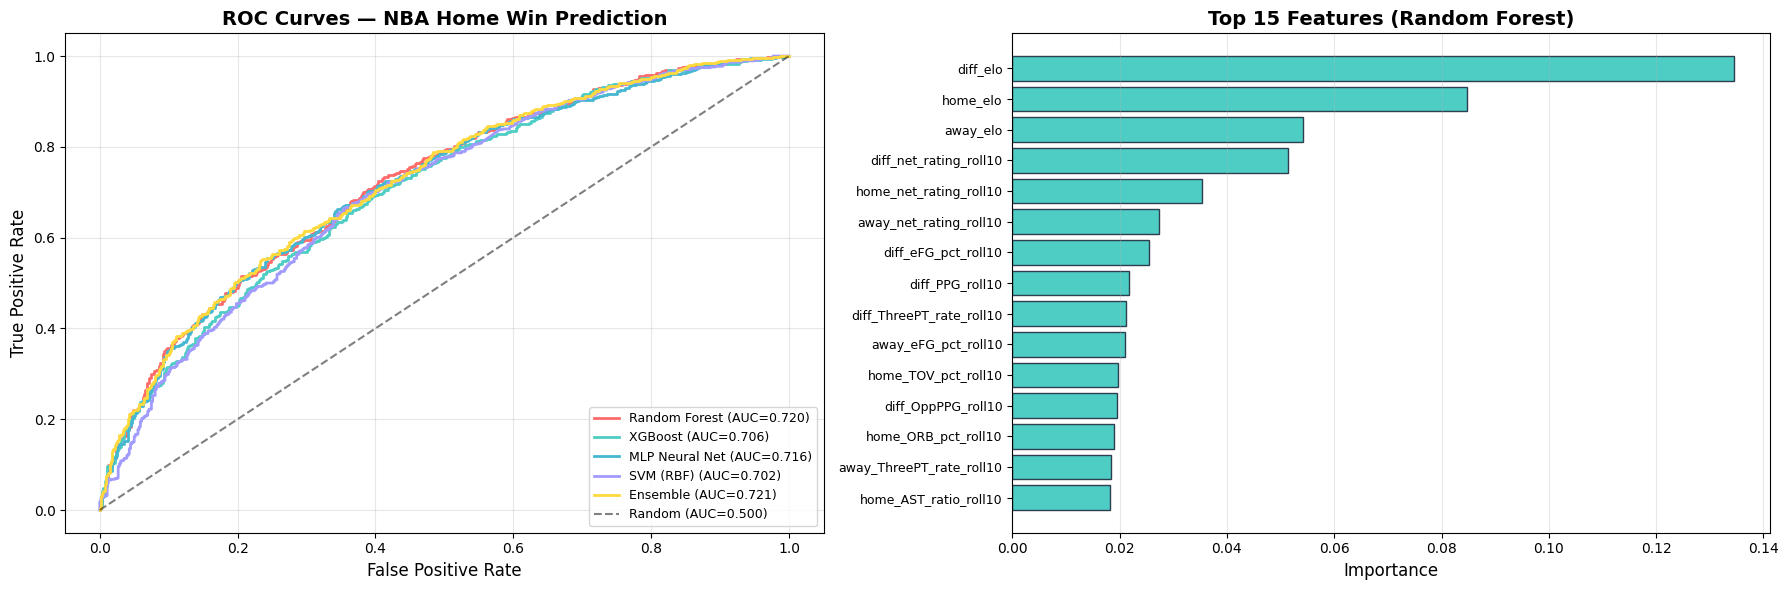

✓ Plots saved to nba_prediction_results.png


In [15]:
# ============================================================
# Cell 15: Visualizations
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
model_specs = [
    ('Random Forest', rf_probs,       '#FF6B6B'),
    ('XGBoost',       xgb_probs,      '#4ECDC4'),
    ('MLP Neural Net',mlp_probs,      '#45B7D1'),
    ('SVM (RBF)',     svm_probs,      '#A29BFE'),
    ('Ensemble',      ensemble_probs, '#FFD93D'),
]
for name, probs, color in model_specs:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves \u2014 NBA Home Win Prediction', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
importances = rf.feature_importances_
indices = np.argsort(importances)[-15:]
ax.barh(range(len(indices)), importances[indices], color='#4ECDC4', edgecolor='#2C3E50')
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([all_feature_cols[i] for i in indices], fontsize=9)
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Top 15 Features (Random Forest)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('nba_prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 Plots saved to nba_prediction_results.png')